# 🤖 Notebook 03 — Phân cụm (EM/GMM) & Phân lớp (Naive Bayes)

**Mục tiêu:**
- **Phân lớp (Classification):** Naive Bayes phân loại bình luận tích cực/tiêu cực
- **Phân cụm (Clustering):** EM/GMM nhóm bình luận theo chủ đề
- Đánh giá mô hình với các metrics phù hợp
- Lưu model để sử dụng trong API

**Đầu vào:** `datas/processed/X_train.npz`, `X_test.npz`, `y_train.npy`, `y_test.npy`  
**Đầu ra:** `datas/models/naive_bayes.pkl`, `datas/models/gmm_model.pkl`

## 1. Import thư viện

In [43]:
import numpy as np
import pandas as pd
import joblib
import warnings
import scipy.sparse as sp
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

# Phân lớp
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score

# Phân cụm
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import TruncatedSVD  # LSA để giảm chiều
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')

ROOT_DIR = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'datas' / 'processed'
MODELS_DIR = ROOT_DIR / 'datas' / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Thư viện đã import thành công')

✅ Thư viện đã import thành công


## 2. Tải dữ liệu đã xử lý

In [44]:
X_train = sp.load_npz(str(PROCESSED_DIR / 'X_train.npz'))
X_test  = sp.load_npz(str(PROCESSED_DIR / 'X_test.npz'))
y_train = np.load(str(PROCESSED_DIR / 'y_train.npy'))
y_test  = np.load(str(PROCESSED_DIR / 'y_test.npy'))

df = pd.read_csv(PROCESSED_DIR / 'processed_reviews.csv')

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}, y_test: {y_test.shape}')
print(f'Train label dist: {pd.Series(y_train).value_counts().to_dict()}')

X_train: (25175, 7851), X_test: (6294, 7851)
y_train: (25175,), y_test: (6294,)
Train label dist: {1: 15482, 0: 9693}


## 3. Phân lớp cảm xúc — Naive Bayes

In [45]:
# --- Huấn luyện Naive Bayes ---
# ComplementNB thường tốt hơn MultinomialNB cho văn bản mất cân bằng
nb_model = ComplementNB(alpha=0.1)
nb_model.fit(X_train, y_train)

# Dự đoán
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

print('=== Kết quả Phân lớp Naive Bayes (ComplementNB) ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: {precision_score(y_test, y_pred):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred):.4f}')
print(f'F1-score:  {f1_score(y_test, y_pred):.4f}')
print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred,
                            target_names=['Tiêu cực', 'Tích cực']))

=== Kết quả Phân lớp Naive Bayes (ComplementNB) ===
Accuracy:  0.7687
Precision: 0.9380
Recall:    0.6680
F1-score:  0.7803

--- Classification Report ---
              precision    recall  f1-score   support

    Tiêu cực       0.64      0.93      0.76      2423
    Tích cực       0.94      0.67      0.78      3871

    accuracy                           0.77      6294
   macro avg       0.79      0.80      0.77      6294
weighted avg       0.82      0.77      0.77      6294



In [46]:
# Cross-validation 5-fold
cv_scores = cross_val_score(nb_model, X_train, y_train, cv=5, scoring='f1')
print(f'Cross-val F1 (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-val F1 (5-fold): 0.7719 ± 0.0022


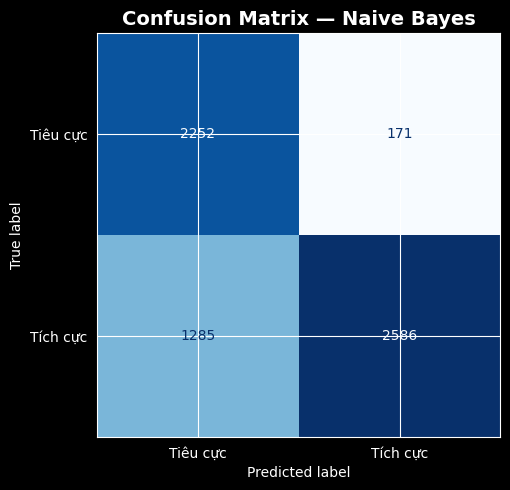

In [47]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Tiêu cực', 'Tích cực'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Naive Bayes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

In [48]:
# --- So sánh MultinomialNB vs ComplementNB ---
results = {}
for name, model in [
    ('MultinomialNB (alpha=1.0)', MultinomialNB(alpha=1.0)),
    ('MultinomialNB (alpha=0.5)', MultinomialNB(alpha=0.5)),
    ('ComplementNB (alpha=0.1)', ComplementNB(alpha=0.1)),
    ('ComplementNB (alpha=0.5)', ComplementNB(alpha=0.5)),
]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-score': f1_score(y_test, pred),
    }

df_results = pd.DataFrame(results).T.round(4)
print('=== So sánh các biến thể Naive Bayes ===')
display(df_results.sort_values('F1-score', ascending=False))

=== So sánh các biến thể Naive Bayes ===


,Accuracy,Precision,Recall,F1-score
MultinomialNB (alpha=1.0),0.7099,0.7087,0.8969,0.7918
MultinomialNB (alpha=0.5),0.7088,0.7100,0.8900,0.7899
ComplementNB (alpha=0.1),0.7687,0.9380,0.6680,0.7803
ComplementNB (alpha=0.5),0.7641,0.9425,0.6564,0.7739


## 4. Phân cụm chủ đề — EM (Gaussian Mixture Model)

In [49]:
# Giảm chiều TF-IDF với Truncated SVD (LSA) trước khi phân cụm
# GMM không hoạt động tốt trên ma trận thưa chiều cao
print('🔄 Giảm chiều với LSA (SVD)...')

N_COMPONENTS = 100  # Giảm xuống 100 chiều
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)

# Dùng toàn bộ dataset cho phân cụm
X_full = sp.vstack([X_train, X_test])
X_reduced = svd.fit_transform(X_full)
X_reduced = normalize(X_reduced)  # L2 normalize

explained_var = svd.explained_variance_ratio_.sum()
print(f'✅ X_reduced shape: {X_reduced.shape}')
print(f'   Explained variance: {explained_var:.2%}')

🔄 Giảm chiều với LSA (SVD)...
✅ X_reduced shape: (31469, 100)
   Explained variance: 32.57%


In [50]:
# Chọn số cụm tối ưu bằng BIC
print('🔄 Đang tìm số cụm tối ưu bằng BIC...')
bic_scores = []
aic_scores = []
n_components_range = range(2, 10)

# Dùng subset để tính nhanh hơn
X_sample = X_reduced[:min(5000, len(X_reduced))]

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='diag',
                          random_state=42, max_iter=200, n_init=3)
    gmm.fit(X_sample)
    bic_scores.append(gmm.bic(X_sample))
    aic_scores.append(gmm.aic(X_sample))
    print(f'  n={n}: BIC={bic_scores[-1]:.0f}, AIC={aic_scores[-1]:.0f}')

optimal_k = n_components_range[np.argmin(bic_scores)]
print(f'\n✅ Số cụm tối ưu theo BIC: {optimal_k}')

🔄 Đang tìm số cụm tối ưu bằng BIC...
  n=2: BIC=-2578807, AIC=-2581421
  n=3: BIC=-2678599, AIC=-2682523
  n=4: BIC=-2726323, AIC=-2731556
  n=5: BIC=-2747531, AIC=-2754074
  n=6: BIC=-2772964, AIC=-2780817
  n=7: BIC=-2787450, AIC=-2796613
  n=8: BIC=-2796026, AIC=-2806499
  n=9: BIC=-2816820, AIC=-2828603

✅ Số cụm tối ưu theo BIC: 9


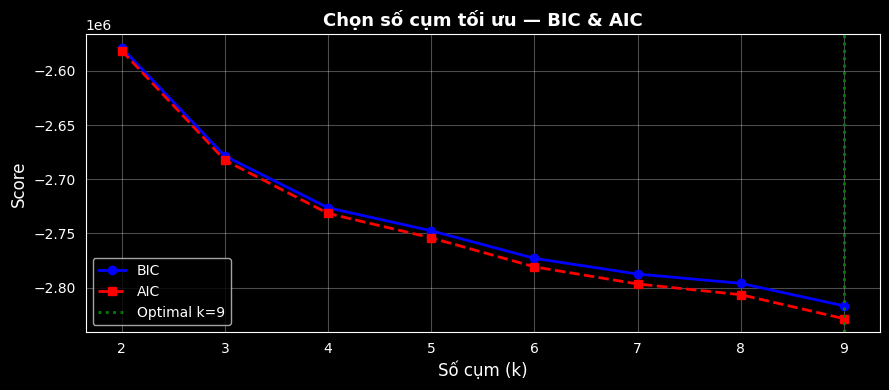

In [51]:
# Biểu đồ BIC/AIC
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(n_components_range), bic_scores, 'b-o', label='BIC', linewidth=2)
ax.plot(list(n_components_range), aic_scores, 'r--s', label='AIC', linewidth=2)
ax.axvline(x=optimal_k, color='green', linestyle=':', linewidth=2,
           label=f'Optimal k={optimal_k}')
ax.set_xlabel('Số cụm (k)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Chọn số cụm tối ưu — BIC & AIC', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'bic_aic_selection.png', dpi=150)
plt.show()

In [52]:
# Huấn luyện GMM với số cụm tối ưu
print(f'🔄 Huấn luyện GMM với k={optimal_k}...')
gmm_model = GaussianMixture(
    n_components=optimal_k,
    covariance_type='diag',
    random_state=42,
    max_iter=300,
    n_init=5,
    verbose=1
)
gmm_model.fit(X_reduced)
cluster_labels = gmm_model.predict(X_reduced)

# Tính Silhouette Score (trên subset để nhanh hơn)
sample_idx = np.random.choice(len(X_reduced), min(3000, len(X_reduced)), replace=False)
sil_score = silhouette_score(X_reduced[sample_idx], cluster_labels[sample_idx])

print(f'\n✅ GMM huấn luyện xong!')
print(f'   Silhouette Score: {sil_score:.4f}')
print(f'   Phân phối cụm: {pd.Series(cluster_labels).value_counts().sort_index().to_dict()}')

🔄 Huấn luyện GMM với k=9...
Initialization 0
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 1
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 2
  Iteration 10
  Iteration 20
  Iteration 30
Initialization converged.
Initialization 3
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
Initialization converged.
Initialization 4
  Iteration 10
  Iteration 20
  Iteration 30
  Iteration 40
  Iteration 50
Initialization converged.

✅ GMM huấn luyện xong!
   Silhouette Score: 0.1522
   Phân phối cụm: {0: 3133, 1: 2797, 2: 1937, 3: 2891, 4: 3135, 5: 1207, 6: 2983, 7: 9725, 8: 3661}


In [53]:
# Gán nhãn chủ đề thủ công sau khi xem top keywords của từng cụm
tfidf = joblib.load(PROCESSED_DIR / 'tfidf_vectorizer.pkl')
feature_names = np.array(tfidf.get_feature_names_out())

# Tìm top-10 từ cho mỗi cụm (qua SVD weights)
TOPIC_LABELS = {}  # Sẽ điền thủ công sau khi xem keywords

print('=== Top 15 từ đại diện cho mỗi cụm ===')
svd_components = svd.components_  # shape: (n_components, n_features)

for cluster_id in range(optimal_k):
    # Tính centroid trong không gian SVD
    cluster_mask = cluster_labels == cluster_id
    centroid_svd = X_reduced[cluster_mask].mean(axis=0)  # (n_components,)
    # Ánh xạ về không gian features gốc
    centroid_original = centroid_svd @ svd_components  # (n_features,)
    top_idx = centroid_original.argsort()[::-1][:15]
    top_words = feature_names[top_idx]
    print(f'  Cụm {cluster_id} ({cluster_mask.sum():,} mẫu): {list(top_words)}')

=== Top 15 từ đại diện cho mỗi cụm ===
  Cụm 0 (3,133 mẫu): ['đẹp', 'vải', 'đi', 'mặc', 'áo', 'mềm', 'shop', 'hàng', 'mịn', 'hơi', 'chất', 'mua', 'to', 'lỗi', 'mát']
  Cụm 1 (2,797 mẫu): ['giá', 'đẹp', 'rẻ', 'giá tiền', 'chất', 'hàng', 'tiền', 'ưng_ý', 'sản_phẩm', 'áo', 'y_hình', 'giày', 'ổn', 'chất_lượng', 'vải']
  Cụm 2 (1,937 mẫu): ['nhiệt_tình', 'shop', 'đẹp', 'dễ_thương', 'tặng', 'chủ', 'form', 'tư_vấn', 'dày', 'váy', 'thất_vọng', 'áo', 'chủ shop', 'shop nhiệt_tình', 'tư_vấn nhiệt_tình']
  Cụm 3 (2,891 mẫu): ['đẹp', 'sản_phẩm', 'đóng_gói', 'đóng_gói sản_phẩm', 'tuyệt_vời', 'phục_vụ', 'chắc_chắn', 'sản_phẩm đẹp', 'chất_lượng', 'sản_phẩm tuyệt_vời', 'chất_lượng sản_phẩm tuyệt_vời', 'đóng_gói sản_phẩm đẹp', 'chất_lượng sản_phẩm', 'đẹp chắc_chắn', 'sản_phẩm đẹp chắc_chắn']
  Cụm 4 (3,135 mẫu): ['áo', 'mặc', 'vải', 'hơi', 'đẹp', 'mỏng', 'ưng', 'rộng', 'size', 'quần', 'xấu', 'chất', 'hàng', 'nói_chung', 'may']
  Cụm 5 (1,207 mẫu): ['ng', 'hang', 'đi', 'dep', 'ngon', 'rat', 'kg', 'ha', '

In [54]:
# === Điền nhãn chủ đề dựa trên top keywords ở trên ===
# Ví dụ (điều chỉnh theo kết quả thực tế):
TOPIC_LABELS = {
    0: 'Chất lượng sản phẩm',
    1: 'Giao hàng & Vận chuyển',
    2: 'Đóng gói',
    3: 'Giá cả & Khuyến mãi',
    4: 'Dịch vụ khách hàng',
}
# Cập nhật theo optimal_k thực tế

# Thêm nhãn cụm vào DataFrame
df['cluster'] = cluster_labels
df['cluster_name'] = df['cluster'].map(TOPIC_LABELS)

print('Phân phối cụm theo chủ đề:')
display(df.groupby(['cluster_name', 'label']).size().unstack(fill_value=0))

Phân phối cụm theo chủ đề:


label,0,1
cluster_name,,
Chất lượng sản phẩm,1223,1910
Dịch vụ khách hàng,1181,1954
Giao hàng & Vận chuyển,1089,1708
Giá cả & Khuyến mãi,1115,1776
Đóng gói,733,1204


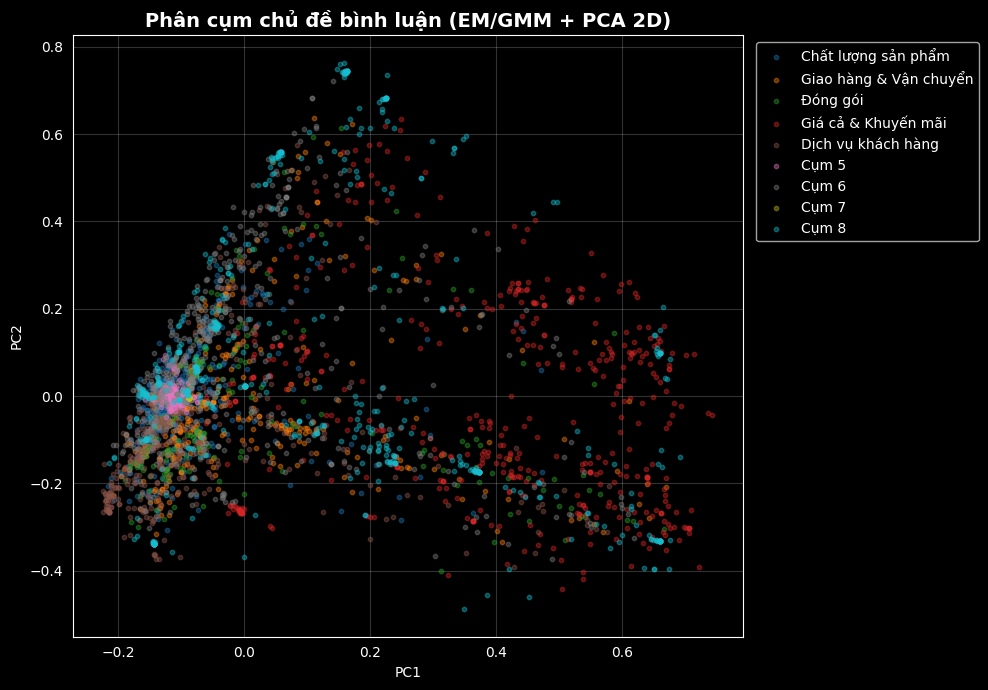

✅ Biểu đồ phân cụm đã lưu


In [55]:
# Visualize phân cụm với 2D (PCA)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_reduced[:5000])  # Subset để vẽ nhanh
labels_2d = cluster_labels[:5000]

colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
fig, ax = plt.subplots(figsize=(10, 7))

for cid in range(optimal_k):
    mask = labels_2d == cid
    topic = TOPIC_LABELS.get(cid, f'Cụm {cid}')
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=[colors[cid]], label=topic, alpha=0.4, s=10)

ax.set_title('Phân cụm chủ đề bình luận (EM/GMM + PCA 2D)',
             fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'clustering_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ phân cụm đã lưu')

## 5. Lưu Models

In [56]:
# Lưu Naive Bayes model
joblib.dump(nb_model, MODELS_DIR / 'naive_bayes.pkl')

# Lưu GMM model
joblib.dump(gmm_model, MODELS_DIR / 'gmm_model.pkl')

# Lưu SVD transformer
joblib.dump(svd, MODELS_DIR / 'svd_transformer.pkl')

# Lưu DataFrame với nhãn cụm
df.to_csv(PROCESSED_DIR / 'reviews_with_clusters.csv',
          index=False, encoding='utf-8-sig')

# Lưu thông tin topic labels
import json
with open(MODELS_DIR / 'topic_labels.json', 'w', encoding='utf-8') as f:
    json.dump(TOPIC_LABELS, f, ensure_ascii=False, indent=2)

print('✅ Phase 3 hoàn thành! Các file đã lưu:')
print('  - datas/models/naive_bayes.pkl')
print('  - datas/models/gmm_model.pkl')
print('  - datas/models/svd_transformer.pkl')
print('  - datas/models/topic_labels.json')
print('  - datas/processed/reviews_with_clusters.csv')

✅ Phase 3 hoàn thành! Các file đã lưu:
  - datas/models/naive_bayes.pkl
  - datas/models/gmm_model.pkl
  - datas/models/svd_transformer.pkl
  - datas/models/topic_labels.json
  - datas/processed/reviews_with_clusters.csv
